In [1]:
import os
import pandas as pd
from tqdm import tqdm
from sent_sampling.utils.data_utils import RESULTS_DIR
from sent_sampling.utils import extract_pool
from sent_sampling.utils.optim_utils import optim_pool, pt_create_corr_rdm_short
from sent_sampling.utils.data_utils import RESULTS_DIR, save_obj,SAVE_DIR,load_obj, ANALYZE_DIR, LEX_PATH_SET
import torch
import numpy as np
from sent_sampling.utils import extract_pool, make_shorthand
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#args = parser.parse_args()
from scipy.stats import mannwhitneyu, ks_2samp
from sent_sampling.utils.data_utils import find_best_match
import os
import torch
from tqdm import tqdm
import numpy as np
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import torch
from sent_sampling.utils import make_shorthand
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import pickle
import numpy as np
import time
from scipy.stats import ks_2samp
from scipy.stats import shapiro, anderson, kstest, norm, probplot
import seaborn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
colors = [  np.divide((255, 153, 51), 255),np.divide((160, 160, 160), 256),np.divide((51, 153, 255), 255),]

/om/user/ehoseini/miniconda3/envs/neural_nlp_2022/lib/python3.8/site-packages/brainscore/metrics/__init__.py:37: FutureWarning: xarray subclass Score should explicitly define __slots__
  class Score(DataAssembly):
/om/user/ehoseini/miniconda3/envs/neural_nlp_2022/lib/python3.8/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/om/user/ehoseini/miniconda3/envs/neural_nlp_2022/lib/python3.8/site-packages/transformers/utils/hub.py:123: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2024-08-12 11:11:11.315979: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /cm/sha

In [25]:
# setup the kl values 
# define optimization file to read out 
n_samples=200
n_selected=196

kl_muliplier = 5.0
kl_threshold = 0.05
bins = 200
epsilon = 1e-10

In [21]:
# define the extraction and optimizer : 
extract_id = 'group=best_performing_pereira_1-dataset=ud_sentencez_token_filter_v3_minus_ev_sentences_textNoPeriod-activation-bench=None-ave=False'

optimizer_id = f"coordinate_ascent_eh-obj=D_s_kl_div-n_iter=50-n_samples={n_samples}-n_init=1-low_dim=False-pca_var=0.9-pca_type=pytorch-run_gpu=True"
#optimizer_id = f"coordinate_ascent_eh-obj=D_s-n_iter=50-n_samples=225-n_init=1-low_dim=False-pca_var=0.9-pca_type=pytorch-run_gpu=True"
extractor_obj = extract_pool[extract_id]()
extractor_obj.load_dataset();
extractor_obj();
optimizer_obj = optim_pool[optimizer_id]();
optimizer_obj.load_extractor(extractor_obj);
low_resolution = False;
optimizer_obj.precompute_corr_rdm_on_gpu(low_resolution=low_resolution, cpu_dump=False, preload=False,
                                         save_results=False);
max_vals=[]
min_vals=[]
idx = np.triu_indices(optimizer_obj.XY_corr_list[0].shape[0], k=1)
for i_m in range(len(optimizer_obj.XY_corr_list)):
    vals = optimizer_obj.XY_corr_list[i_m][idx]
    print(f'model: {extractor_obj.model_spec[i_m]}, min: {vals.min()}, max: {vals.max()}')
    # round max to nearest 0.1 and drop the decimal part
    max_vals.append(torch.ceil(vals.max() * 10) / 10)
    min_vals.append(torch.floor(vals.min() * 10) / 10)
# extract ev sentences
# find location of ev sentences in sentences
random_hist = []
XY_corr_hist_list = []
bins = 200
epsilon = 1e-10
for kk in tqdm(range(200)):
    S = np.random.choice(optimizer_obj.N_S, optimizer_obj.N_s, replace=False)
    # compute objective function for the random sample
    samples = torch.tensor(S, dtype=torch.long, device=optimizer_obj.device)
    pairs = torch.combinations(samples, with_replacement=False)
    XY_corr_sample = [XY_corr[pairs[:, 0], pairs[:, 1]].to(optimizer_obj.device) for XY_corr in
                      optimizer_obj.XY_corr_list]
    XY_corr_hist = [torch.histc(x_ref, bins=bins, min=0, max=2) for x_ref in XY_corr_sample]
    XY_corr_hist = [(hist_ref / torch.sum(hist_ref)) + epsilon for hist_ref in XY_corr_hist]
    XY_corr_hist = [p_smooth / p_smooth.sum() for p_smooth in XY_corr_hist]

    XY_corr_hist_list.append(torch.stack(XY_corr_hist))

XY_corr_hist_mean=torch.stack(XY_corr_hist_list,dim=-1).mean(dim=-1)
# normlaize along the last dimension to get a probability distribution per each row
XY_corr_hist_mean = XY_corr_hist_mean / XY_corr_hist_mean.sum(dim=-1, keepdim=True)
XY_corr_hist=torch.stack(XY_corr_hist,dim=0)


kl_div_rnd = []
for kk in tqdm(range(100)):
    S = np.random.choice(optimizer_obj.N_S, optimizer_obj.N_s, replace=False)
    # compute objective function for the random sample
    samples = torch.tensor(S, dtype=torch.long, device=optimizer_obj.device)
    pairs = torch.combinations(samples, with_replacement=False)
    XY_corr_sample = [XY_corr[pairs[:, 0], pairs[:, 1]].to(optimizer_obj.device) for XY_corr in
                      optimizer_obj.XY_corr_list]
    XY_corr_hist = [torch.histc(x_ref, bins=bins, min=min_vals[id_m], max=max_vals[id_m]) for id_m,x_ref in enumerate(XY_corr_sample)]
    XY_corr_hist = [(hist_ref / torch.sum(hist_ref)) + epsilon for hist_ref in XY_corr_hist]
    XY_corr_hist = [p_smooth / p_smooth.sum() for p_smooth in XY_corr_hist]
    XY_corr_hist = torch.stack(XY_corr_hist, dim=0)
    kl_div_pm = (XY_corr_hist * (XY_corr_hist.log() - XY_corr_hist_mean.log())).mean(dim=-1)
    kl_div_rnd.append(kl_div_pm)

kl_div_rnd=torch.stack(kl_div_rnd)
kl_div_rnd_max=kl_div_rnd.max(dim=0)[0]

optimizer_obj.XY_corr_hist_mean = XY_corr_hist_mean
optimizer_obj.bins = bins
optimizer_obj.kl_div_rnd_max=kl_muliplier*kl_div_rnd_max
optimizer_obj.epsilon=1e-10
optimizer_obj.kl_div_threshold=kl_threshold
optimizer_obj.kl_div_muliplier=kl_muliplier
optimizer_obj.corr_min_max=list(zip(min_vals,max_vals))

432it [00:00, 95025.14it/s]
432it [00:00, 161061.27it/s]
432it [00:00, 100234.52it/s]
432it [00:00, 100674.48it/s]
432it [00:00, 101050.66it/s]
432it [00:00, 100378.89it/s]
432it [00:00, 95930.71it/s]
432it [00:00, 100562.73it/s]
432it [00:00, 144366.13it/s]
432it [00:00, 99557.11it/s]
432it [00:00, 107272.47it/s]
432it [00:00, 156701.49it/s]
432it [00:00, 145013.15it/s]
432it [00:00, 107158.28it/s]
432it [00:00, 102178.95it/s]
432it [00:00, 100390.01it/s]
432it [00:00, 158137.49it/s]
432it [00:00, 100803.30it/s]
433it [00:00, 100200.48it/s]


extracting network activations for roberta-base
ud_sentencez_token_filter_v3_minus_ev_sentences_textNoPeriod_roberta-base_layer_2_activation_ave_False.pkl already exists, loading...
loading /nese/mit/group/evlab/u/ehoseini/MyData/sent_sampling/ud_sentencez_token_filter_v3_minus_ev_sentences_textNoPeriod_roberta-base_layer_2_activation_ave_False.pkl
adding activations to set
extracting network activations for xlnet-large-cased
ud_sentencez_token_filter_v3_minus_ev_sentences_textNoPeriod_xlnet-large-cased_layer_24_activation_ave_False.pkl already exists, loading...
loading /nese/mit/group/evlab/u/ehoseini/MyData/sent_sampling/ud_sentencez_token_filter_v3_minus_ev_sentences_textNoPeriod_xlnet-large-cased_layer_24_activation_ave_False.pkl
adding activations to set
extracting network activations for bert-large-uncased-whole-word-masking
ud_sentencez_token_filter_v3_minus_ev_sentences_textNoPeriod_bert-large-uncased-whole-word-masking_layer_12_activation_ave_False.pkl already exists, loading

7it [00:23,  3.36s/it]


model: roberta-base, min: 0.0003044605255126953, max: 0.6717871427536011
model: xlnet-large-cased, min: 0.0013253092765808105, max: 1.944024920463562
model: bert-large-uncased-whole-word-masking, min: 5.960464477539063e-08, max: 0.9394881725311279
model: xlm-mlm-en-2048, min: 1.1920928955078125e-07, max: 1.3224915266036987
model: gpt2-xl, min: 0.0017224550247192383, max: 0.9066860675811768
model: albert-xxlarge-v2, min: 0.05449199676513672, max: 1.02857506275177
model: ctrl, min: 0.00622183084487915, max: 0.5653496980667114


100%|██████████| 100/100 [00:00<00:00, 186.82it/s]


In [26]:

optimizer_id_max = f"coordinate_ascent_eh-obj=D_s_kl_div-n_iter=50-n_samples={n_samples}-n_init=1-low_dim=False-pca_var=0.9-pca_type=pytorch-run_gpu=True"

[ext_id, opt_id_max] = make_shorthand(extract_id, optimizer_id_max)
optim_file = os.path.join(RESULTS_DIR,
                          f'res_{ext_id}_{opt_id_max}_kl_thr_{kl_threshold}_mult_{kl_muliplier}_bins_{bins}_norm.pkl')

# check when the file was created

if os.path.exists(optim_file):
    modification_time = os.path.getmtime(optim_file)
    modification_date = time.ctime(modification_time)
    print(f"The file was last modified on: {modification_date}")
    optim_max = load_obj(optim_file)
else:
    print(f"File {optim_file} not found")

# load optim_max
optimizer_id_min = f"coordinate_ascent_eh-obj=2-D_s_kl_div-n_iter=50-n_samples={n_samples}-n_init=1-low_dim=False-pca_var=0.9-pca_type=pytorch-run_gpu=True"
[ext_id, opt_id_min] = make_shorthand(extract_id, optimizer_id_min)
optim_file = os.path.join(RESULTS_DIR,
                          f'res_{ext_id}_{opt_id_min}_kl_thr_{kl_threshold}_mult_{kl_muliplier}_bins_{bins}_norm.pkl')
if os.path.exists(optim_file):
    modification_time = os.path.getmtime(optim_file)
    modification_date = time.ctime(modification_time)
    print(f"The file was last modified on: {modification_date}")
    optim_min = load_obj(optim_file)
else:
    print(f"File {optim_file} not found")

The file was last modified on: Sun Aug 11 23:40:10 2024
loading /nese/mit/group/evlab/u/ehoseini/MyData/sent_sampling/results/res_G=best_performing_pereira_1-D=ud_sentencez_token_filter_v3_minus_ev_sentences_textNoPeriod-activation-B=None-AVE=False_coordinate_ascent_eh-O=D_s_kl_div-Nit=50-Ns=200-Nin=1-LD=False-V=0.9-T=pytorch-GPU=True_kl_thr_0.05_mult_5.0_bins_200_norm.pkl
The file was last modified on: Mon Aug 12 00:00:31 2024
loading /nese/mit/group/evlab/u/ehoseini/MyData/sent_sampling/results/res_G=best_performing_pereira_1-D=ud_sentencez_token_filter_v3_minus_ev_sentences_textNoPeriod-activation-B=None-AVE=False_coordinate_ascent_eh-O=2-D_s_kl_div-Nit=50-Ns=200-Nin=1-LD=False-V=0.9-T=pytorch-GPU=True_kl_thr_0.05_mult_5.0_bins_200_norm.pkl


# inspecting sentences  

In [92]:
ds_min_loc=optim_min['optimized_S']
ds_max_loc=optim_max['optimized_S']
act_dict=extractor_obj.model_group_act[0]
sentences = [x[1] for x in act_dict['activations']]
ds_min_sent=[sentences[x] for x in ds_min_loc]
ds_max_sent=[sentences[x] for x in ds_max_loc]
data_text = [x['text'] for x in extractor_obj.data_]
data_textNoPeriod = []
for x in data_text:
    if '.' in x[-1]:
        data_textNoPeriod.append(x[:-1])
    else:
        data_textNoPeriod.append(x)
# drop the space in the end if it exist in data_textNoPeriod
data_textNoPeriod = [x if x[-1] != ' ' else x[:-1] for x in data_textNoPeriod]

In [27]:
# load the file with ax_title+'_included.xlsx'


# create a random set of sentences 

In [88]:
optim_id_random=f"coordinate_ascent_eh-obj=D_s_rand_kl_div-n_iter=50-n_samples={n_samples}-n_init=1-low_dim=False-pca_var=0.9-pca_type=pytorch-run_gpu=True"
[ext_id, opt_id_rand] = make_shorthand(extract_id, optim_id_random)
optim_file_rand = os.path.join(RESULTS_DIR,
                          f'res_{ext_id}_{opt_id_rand}_kl_thr_{kl_threshold}_mult_{kl_muliplier}_bins_{bins}_norm.pkl')
# if path ds_rand_path exists, load it
if Path(optim_file_rand).exists():
    with open(optim_file_rand.__str__(), 'rb') as f:
        results_ds_rand = pickle.load(f)

else:
    ds_rand = []
    
    RDM_rand = []
    sent_random_set=[]
    # drop ds_min_loc_incl and ds_max_loc_incl from the list of possible sentences
    all_sentence_set = set(range(optimizer_obj.N_S))
    all_sentence_set = all_sentence_set - set(ds_min_loc)
    all_sentence_set = all_sentence_set - set(ds_max_loc)
    all_sentence_set = list(all_sentence_set)
    for k in tqdm(enumerate(range(1000))):
        sent_random = list(np.random.choice(all_sentence_set, optimizer_obj.N_s,replace=False))
        d_s_r, RDM_r = optimizer_obj.gpu_object_function_debug(sent_random)
        ds_rand.append(d_s_r)
        RDM_rand.append(RDM_r[np.triu_indices(RDM_r.shape[0], k=+1)].cpu().numpy())
        sent_random_set.append(sent_random)
    # find ds_rand closest to mean
    x_mean=np.mean(ds_rand) - np.array(ds_rand)
    y_std=np.std(RDM_rand,axis=1)
    id_low_mean_std=np.argmin(x_mean**2+y_std**2)
    ds_rand_loc = sent_random_set[id_low_mean_std]
    results_ds_rand = dict(extractor_name='',
                             model_spec='',
                             layer_spec='',
                             optimizatin_name=optim_id_random,
                             optimized_S=ds_rand_loc,
                             optimized_d=ds_rand[id_low_mean_std])
    save_obj(results_ds_rand, optim_file_rand)
ds_rand_loc=results_ds_rand['optimized_S']

In [93]:
# pandas dataframe with the following columns: ds_max_loc, ds_max_sent,include, ds_min_loc, ds_min_sent, include, and set the include to 1
df = pd.DataFrame({'ds_max_loc': ds_max_loc, 'ds_max_sent': ds_max_sent, 'ds_max_include': 1, 'ds_min_loc': ds_min_loc, 'ds_min_sent': ds_min_sent, 'ds_min_include': 1, 'ds_rand_loc': ds_rand_loc, 'ds_rand_sent': [sentences[x] for x in ds_rand_loc], 'ds_rand_include': 1})
(ext_sh, optim_sh) = make_shorthand(extract_id, optimizer_id)
ax_title = f'sentences,{ext_sh}_Ns={n_samples}_kl_div_thr_{kl_threshold}_mult_{kl_muliplier}_bins_{bins}'
save_path = Path(ANALYZE_DIR)
# save the df as a excel file
df.to_excel(save_path / f'{ax_title}.xlsx')

In [94]:
df_incl = pd.read_excel(save_path / f'{ax_title}_included.xlsx')

In [95]:
# chose df_max as from columns ds_max_sent, ds_max_loc, ds_max_include
df_max = df_incl[['ds_max_sent', 'ds_max_loc', 'ds_max_include']]
# select rows with ds_max_include == 1
df_max = df_max[df_max['ds_max_include'] == 1]
ds_max_loc_incl = df_max['ds_max_loc'].tolist()
ds_max_sent_incl = df_max['ds_max_sent'].tolist()
# make it int 
ds_max_loc_incl = [int(x) for x in ds_max_loc_incl]
# do the same for min 
df_min = df_incl[['ds_min_sent', 'ds_min_loc', 'ds_min_include']]
df_min = df_min[df_min['ds_min_include'] == 1]
ds_min_loc_incl = df_min['ds_min_loc'].tolist()
ds_min_loc_incl = [int(x) for x in ds_min_loc_incl]
ds_min_sent_incl = df_min['ds_min_sent'].tolist()
# do the same for rand
df_rand = df_incl[['ds_rand_sent', 'ds_rand_loc', 'ds_rand_include']]
df_rand = df_rand[df_rand['ds_rand_include'] == 1]
ds_rand_loc_incl = df_rand['ds_rand_loc'].tolist()
ds_rand_loc_incl = [int(x) for x in ds_rand_loc_incl]
ds_rand_sent_incl = df_rand['ds_rand_sent'].tolist()
# assert len of ds_min_loc_incl and ds_max_loc_incl is 200
assert len(ds_min_loc_incl) == n_selected
assert len(ds_max_loc_incl) == n_selected
assert len(ds_rand_loc_incl) == n_selected

In [96]:
ds_rand_loc = np.random.choice(ds_rand_loc_incl, n_selected, replace=False)
ds_min_loc = np.random.choice(ds_min_loc_incl, n_selected, replace=False)
ds_max_loc = np.random.choice(ds_max_loc_incl, n_selected, replace=False)
ds_rand_sent = [sentences[x] for x in ds_rand_loc]
ds_min_sent = [sentences[x] for x in ds_min_loc]
ds_max_sent = [sentences[x] for x in ds_max_loc]
d_s_min, RDM_min = optimizer_obj.gpu_object_function_debug(ds_min_loc)
[ds_kl_min, _, kl_div_min]=optimizer_obj.gpu_object_function_ds_kl_div(ds_min_loc, debug=True)
d_s_rand, RDM_rand = optimizer_obj.gpu_object_function_debug(ds_rand_loc)
[ds_kl_rand, _, kl_div_rand]=optimizer_obj.gpu_object_function_ds_kl_div(ds_rand_loc, debug=True)
d_s_max, RDM_max = optimizer_obj.gpu_object_function_debug(ds_max_loc)
[ds_kl_max, _, kl_div_max]=optimizer_obj.gpu_object_function_ds_kl_div(ds_max_loc, debug=True)
RDM_min=2-RDM_min.cpu()
RDM_rand=2-RDM_rand.cpu()
RDM_max = 2-RDM_max.cpu()
RDM_max = np.triu(RDM_max, k=1).T + np.triu(RDM_max, k=1)
RDM_min = np.triu(RDM_min, k=1).T + np.triu(RDM_min, k=1)
RDM_rand = np.triu(RDM_rand, k=1).T + np.triu(RDM_rand, k=1)
rdm_rand_vec = RDM_rand[np.tril_indices(RDM_max.shape[0], k=-1)]
rdm_max_vec = RDM_max[np.tril_indices(RDM_max.shape[0], k=-1)]
rdm_min_vec = RDM_min[np.tril_indices(RDM_max.shape[0], k=-1)]
RDM_Mix=np.triu(RDM_min)+np.tril(RDM_max)
model_names_sh=['roberta','xlnet-L','bert-L','xlm','gpt2-xl','albert-xxl','ctrl']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


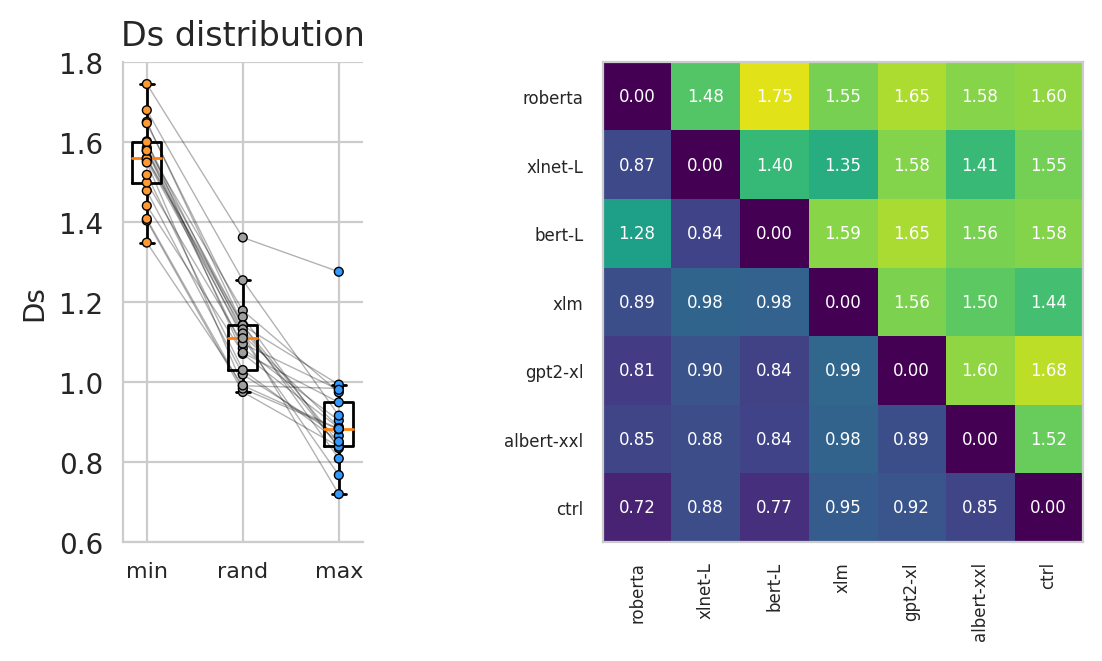

In [97]:
fig = plt.figure(figsize=(8, 11), dpi=200, frameon=False)
pap_ratio = 8 / 11
ax = plt.axes((.1, .1, .15, .3 * pap_ratio))
rdm_vec = np.vstack((rdm_min_vec, rdm_rand_vec, rdm_max_vec))
# plot one line per column in rdm_vec
for i in range(rdm_vec.shape[1]):
    ax.plot([1, 2, 3], rdm_vec[:, i], color='k', alpha=.3, linewidth=.5, zorder=1)
    # plot a scatter with each point color same as color_set
    ax.scatter([1, 2, 3], rdm_vec[:, i], color=colors, s=10, marker='o', alpha=1, zorder=2, edgecolors='k', linewidths=.5)
# use a boxplot to show the distribution of rdm values per row, with colors matching above scatter plot

ax.boxplot(rdm_vec.transpose(), vert=True, showfliers=False, showmeans=False,
           meanprops={'marker': 'o', 'markerfacecolor': 'r', 'markeredgecolor': 'k'},zorder=1)
# set xtick labels to ds_min, ds_rand, ds_max
ax.set_xticklabels(['min', 'rand', 'max'], fontsize=8)
ax.set_ylabel('Ds')
ax.set_ylim((.6, 1.8))
ax.set_title('Ds distribution')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim((.75, 3.25))

# ax.violinplot([0,1,2],rdm_vec.transpose(),showmeans=True,showextrema=False,showmedians=False)
ax = plt.axes((.4, .1, .3, .3 * pap_ratio))
im = ax.imshow(RDM_Mix, cmap='viridis',vmin=.6, vmax=1.8)
# add values to image plot
for i in range(RDM_Mix.shape[0]):
    for j in range(RDM_Mix.shape[1]):
        text = ax.text(j, i, f'{RDM_Mix[i, j]:.2f}',
                       ha="center", va="center", color="w", fontsize=6)
ax.set_yticks(np.arange(len(extractor_obj.model_spec)))
ax.set_yticklabels(model_names_sh, fontsize=6)
ax.set_xticks(np.arange(len(extractor_obj.model_spec)))
ax.set_xticklabels(model_names_sh, fontsize=6, rotation=90)
# set 
# turn of greed 
ax.grid(False)
save_path = Path(ANALYZE_DIR)

ax_title = f'ds,{ext_sh}_Ns={n_samples}_N_selected={n_selected}_kl_div_thr_{kl_threshold}_mult_{kl_muliplier}_bins_{bins}'
save_loc = Path(save_path.__str__(), f'{ax_title}.png')
fig.savefig(save_loc.__str__(), format='png', metadata=None, bbox_inches=None, pad_inches=0.1, dpi=350,facecolor='auto',edgecolor='auto', backend=None)
save_loc = Path(save_path.__str__(), f'{ax_title}.eps')
fig.savefig(save_loc.__str__(), format='eps', metadata=None, bbox_inches=None, pad_inches=0.1,facecolor='auto',edgecolor='auto', backend=None)


# lexical features

In [100]:
ds_min_loc_in_dat=[]
ds_max_loc_in_dat=[]
ds_rand_loc_in_dat=[]
for x in ds_min_sent:
    x_new = find_best_match(x, data_textNoPeriod)
    ds_min_loc_in_dat.append(data_textNoPeriod.index(x_new))
for x in ds_max_sent:
    x_new = find_best_match(x, data_textNoPeriod)
    ds_max_loc_in_dat.append(data_textNoPeriod.index(x_new))
for x in ds_rand_sent:
    x_new = find_best_match(x, data_textNoPeriod)
    ds_rand_loc_in_dat.append(data_textNoPeriod.index(x_new))
sent_max_data = [extractor_obj.data_[x] for x in ds_max_loc_in_dat]
sent_min_data = [extractor_obj.data_[x] for x in ds_min_loc_in_dat]
sent_rand_data = [extractor_obj.data_[x] for x in ds_rand_loc_in_dat]
sent_all_data=extractor_obj.data_
lex_names = [x['name'] for x in LEX_PATH_SET]
sent_max_lex_values = [[np.nanmean(sent_dat[lex_name]) for lex_name in lex_names] for sent_dat in sent_max_data]
sent_min_lex_values = [[np.nanmean(sent_dat[lex_name]) for lex_name in lex_names] for sent_dat in sent_min_data]
sent_rand_lex_values = [[np.nanmean(sent_dat[lex_name]) for lex_name in lex_names] for sent_dat in sent_rand_data]
sent_all_lex_values = [[np.nanmean(sent_dat[lex_name]) for lex_name in lex_names] for sent_dat in sent_all_data]
# add num_words to the beginning of each list
sent_max_num_words = [len(x['word_id']) for x in sent_max_data]
sent_min_num_words = [len(x['word_id']) for x in sent_min_data]
sent_rand_num_words = [len(x['word_id']) for x in sent_rand_data]
sent_all_num_words = [len(x['word_id']) for x in sent_all_data]
sent_max_lex_values = np.concatenate([np.asarray(sent_max_num_words).reshape(-1, 1), np.asarray(sent_max_lex_values)], axis=1)
sent_min_lex_values = np.concatenate([np.asarray(sent_min_num_words).reshape(-1, 1), np.asarray(sent_min_lex_values)], axis=1)
sent_rand_lex_values = np.concatenate([np.asarray(sent_rand_num_words).reshape(-1, 1), np.asarray(sent_rand_lex_values)], axis=1)
sent_all_lex_values = np.concatenate([np.asarray(sent_all_num_words).reshape(-1, 1), np.asarray(sent_all_lex_values)], axis=1)
lex_names = [x['name'] for x in LEX_PATH_SET]
lex_dict = {lex_name: [] for lex_name in lex_names}
ds_max_lex = {lex_name: [] for lex_name in lex_names}
for lex_name in lex_names:
    lex_values = [np.nanmean(sent_dat[lex_name]) for sent_dat in sent_max_data]
    ds_max_lex[lex_name] = lex_values
# add a new field for number of words
ds_max_lex['num_words'] = sent_max_num_words
ds_min_lex = {lex_name: [] for lex_name in lex_names}
for lex_name in lex_names:
    lex_values = [np.nanmean(sent_dat[lex_name]) for sent_dat in sent_min_data]
    ds_min_lex[lex_name] = lex_values
# add a new field for number of words
ds_min_lex['num_words'] = sent_min_num_words

ds_rand_lex = {lex_name: [] for lex_name in lex_names}
for lex_name in lex_names:
    lex_values = [np.nanmean(sent_dat[lex_name]) for sent_dat in sent_all_data]
    ds_rand_lex[lex_name] = lex_values
# add a new field for number of words
ds_rand_lex['num_words'] = sent_rand_num_words
lex_names = ['num_words'] + lex_names

/tmp/ipykernel_978146/2978503376.py:19: RuntimeWarning: Mean of empty slice
  sent_min_lex_values = [[np.nanmean(sent_dat[lex_name]) for lex_name in lex_names] for sent_dat in sent_min_data]
/tmp/ipykernel_978146/2978503376.py:21: RuntimeWarning: Mean of empty slice
  sent_all_lex_values = [[np.nanmean(sent_dat[lex_name]) for lex_name in lex_names] for sent_dat in sent_all_data]
/tmp/ipykernel_978146/2978503376.py:41: RuntimeWarning: Mean of empty slice
  lex_values = [np.nanmean(sent_dat[lex_name]) for sent_dat in sent_min_data]
/tmp/ipykernel_978146/2978503376.py:48: RuntimeWarning: Mean of empty slice
  lex_values = [np.nanmean(sent_dat[lex_name]) for sent_dat in sent_all_data]


/tmp/ipykernel_978146/3808804776.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seaborn.distplot(sent_all_lex_values[:, i], bins=50, label='Ds_all', norm_hist=True, hist=False, ax=axes[i],
/om/user/ehoseini/miniconda3/envs/neural_nlp_2022/lib/python3.8/site-packages/seaborn/distributions.py:2497: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if kde_color != color:
/tmp/ipykernel_978146/3808804776.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level func

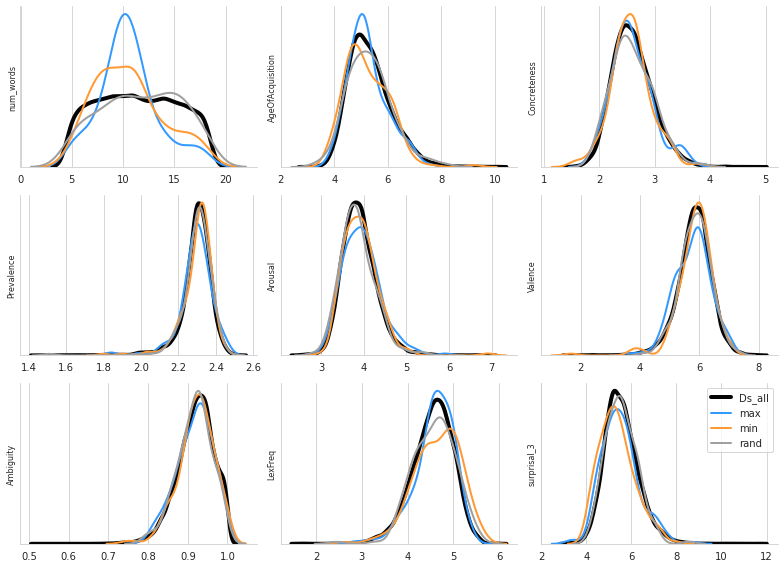

In [101]:
assert len(lex_names) == sent_max_lex_values.shape[1]
# create a figure with 3 rows and 3 columns
fig, axes = plt.subplots(3, 3, figsize=(11, 8))
axes = axes.flatten()
for i in range(len(lex_names)):
    # plot a histogram for sent_max_lex_values using seaborn.distplot on axes[i]
    seaborn.distplot(sent_all_lex_values[:, i], bins=50, label='Ds_all', norm_hist=True, hist=False, ax=axes[i],
                     kde_kws={"lw": 4, "color": np.divide([4, 4, 4], 255)});
    seaborn.distplot(sent_max_lex_values[:, i], bins=50, label='max', norm_hist=True, hist=False, ax=axes[i],
                     kde_kws={"lw": 2, "color": colors[2]});
    seaborn.distplot(sent_min_lex_values[:, i], bins=50, label='min', norm_hist=True, hist=False, ax=axes[i],
                     kde_kws={"lw": 2, "color": colors[0]});
    seaborn.distplot(sent_rand_lex_values[:, i], bins=50, label='rand', norm_hist=True, hist=False, ax=axes[i],
                        kde_kws={"lw": 2, "color": colors[1]});
    # put tick in the begining and end of x axis
    # axes[i].set_xticks([np.min(sent_all_lex_values[:, i]), np.max(sent_all_lex_values[:, i])])
    if i == (len(lex_names) - 1):
        axes[i].legend(loc='upper right')
    axes[i].set_ylabel(lex_names[i], fontsize=8)
    # remove top and right spines
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    # turn off yticks values
    axes[i].set_yticks([])

plt.tight_layout()
fig.show()
ax_title = f's_feat,{ext_sh}_Ns={n_samples}_N_selected={n_selected}_kl_div_thr_{kl_threshold}_mult_{kl_muliplier}_bins_{bins}'
save_loc = Path(save_path.__str__(), f'{ax_title}.png')
fig.savefig(save_loc.__str__(), format='png', metadata=None, bbox_inches=None, pad_inches=0.1, dpi=350,facecolor='auto',edgecolor='auto', backend=None)
save_loc = Path(save_path.__str__(), f'{ax_title}.eps')
fig.savefig(save_loc.__str__(), format='eps', metadata=None, bbox_inches=None, pad_inches=0.1,facecolor='auto',edgecolor='auto', backend=None)


# inspecting RDMs for models 

In [103]:
X_Min = []
X_max = []
X_mix_min = []
X_mix_max = []
X_rand = []
for XY_corr in optimizer_obj.XY_corr_list:
    pairs = torch.combinations(torch.tensor(ds_min_loc), with_replacement=False)
    x_min= 2-XY_corr[pairs[:, 0], pairs[:, 1]]
    x_min = squareform(x_min)
    X_Min.append(x_min)
    pairs = torch.combinations(torch.tensor(ds_max_loc), with_replacement=False)
    x_max = 2-XY_corr[pairs[:, 0], pairs[:, 1]]
    x_max = squareform(x_max)
    X_max.append(x_max)
    
    pairs=torch.combinations(torch.tensor(ds_rand_loc), with_replacement=False)
    x_rand = 2-XY_corr[pairs[:, 0], pairs[:, 1]]
    x_rand = squareform(x_rand)
    
    
    eye_matrix = np.eye(x_min.shape[0])
    eye_matrix[eye_matrix == 1] = np.nan
    X_mix_min.append(np.tril(x_rand)+np.triu(x_min)+eye_matrix) 
    X_mix_max.append(np.tril(x_rand)+np.triu(x_max)+eye_matrix)

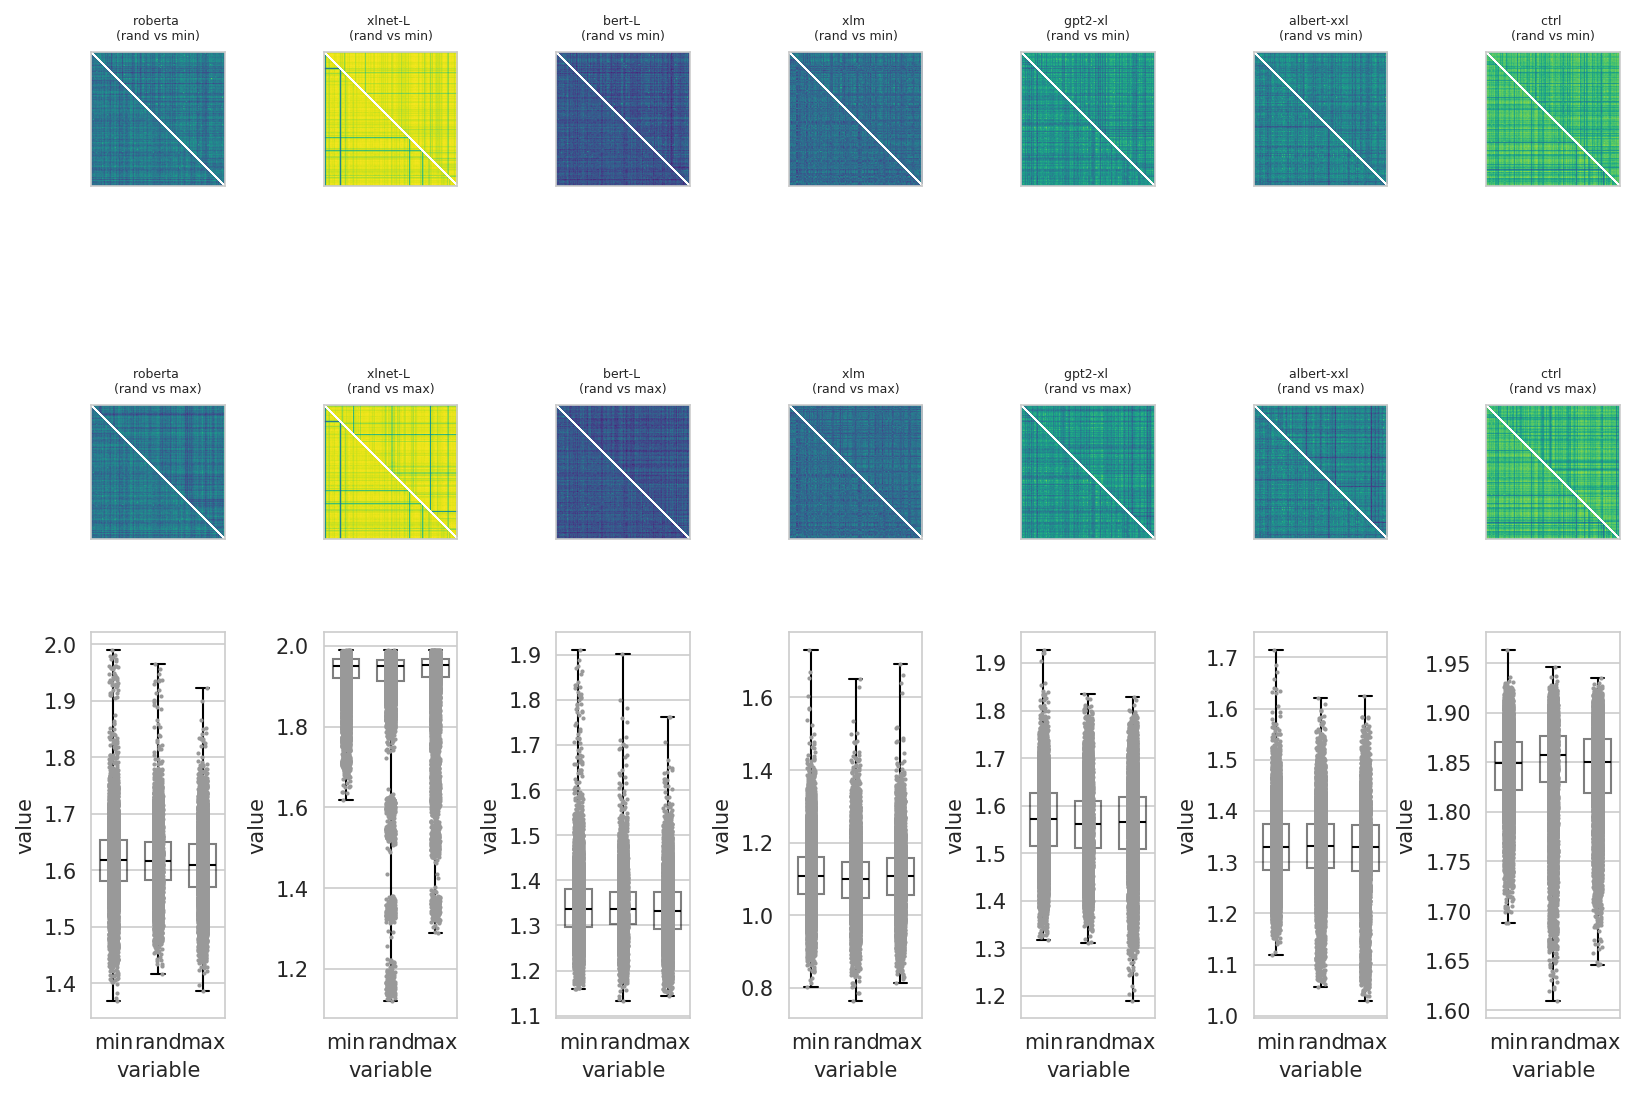

In [113]:
fig = plt.figure(figsize=(11, 8),dpi=150)
for i in range(len(X_mix_min)):
    ax = plt.subplot(3, 7, i + 1)
    x_=X_mix_min[i]
    x_1=X_mix_max[i]
    vmin=np.nanmin(np.stack([x_,x_1]))
    vmax=np.nanmax(np.stack([x_,x_1]))
    im = ax.imshow(x_, cmap='viridis', vmax=vmax,vmin=vmin)
    ax.set_title(f'{model_names_sh[i]} \n(rand vs min)', fontsize=6)
    # turn off ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax = plt.subplot(3, 7, i + 1 + 7)
    x_=X_mix_max[i]
    im = ax.imshow(x_, cmap='viridis', vmax=vmax,vmin=vmin)
    ax.set_title(f'{model_names_sh[i]}', fontsize=6)
    # turn off ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{model_names_sh[i]} \n(rand vs max)', fontsize=6)
    
    ax = plt.subplot(3, 7, i + 1 + 14)

    a_max = X_mix_max[i][np.triu_indices(x_.shape[0], k=1)]
    a_min = X_mix_min[i][np.triu_indices(x_.shape[0], k=1)]
    a_rand= X_mix_min[i][np.tril_indices(x_.shape[0], k=-1)]
    df = pd.DataFrame(np.vstack((a_min, a_rand,a_max)).transpose(), columns=['min','rand','max'])
    df_long = pd.melt(df)
    seaborn.stripplot(data=df_long, x="variable", y="value", size=2, color=".6", ax=ax, jitter=True)

# Boxplot with adjusted parameters
    seaborn.boxplot(
    data=df_long, x="variable", y="value", ax=ax, whis=[0, 100], width=.6,
    boxprops=dict(alpha=0.5, facecolor='none', edgecolor='black'),
    whiskerprops=dict(color='black'), capprops=dict(color='black'),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor='black', markeredgecolor='black', alpha=0.5)
    )
plt.tight_layout()

In [114]:
X_mix_min[0].shape[0]

196

# statistical test of distance differences between min and max

In [115]:
X_rands_many = []
all_sentence_set = set(range(optimizer_obj.N_S))
all_sentence_set = all_sentence_set - set(ds_min_loc)
all_sentence_set = all_sentence_set - set(ds_max_loc)
all_sentence_set = all_sentence_set - set(ds_rand_loc)
all_sentence_set = list(all_sentence_set)
for k in tqdm(enumerate(range(500))):
    sent_random = list(np.random.choice(all_sentence_set, X_mix_min[0].shape[0]))
    pairs = torch.combinations(torch.tensor(sent_random), with_replacement=False)
    x_rand_many = []
    for XY_ in optimizer_obj.XY_corr_list:
        X_sample = 2-XY_[pairs[:, 0], pairs[:, 1]].cpu().numpy()
        # make squareform matrix
        X_sample = squareform(X_sample)
        x_rand_many.append(X_sample[np.tril_indices(X_sample.shape[0], k=-1)])
    X_rands_many.append(x_rand_many)
    #%

500it [00:06, 77.56it/s]


In [116]:
sample_list_results = []
for idx in range(len(X_mix_min)):
    x_min_mdl = X_mix_min[idx][np.triu_indices(x_.shape[0], k=1)]
    x_max_mdl = X_mix_max[idx][np.triu_indices(x_.shape[0], k=1)]
    x_rand_mdl = X_mix_min[idx][np.tril_indices(x_.shape[0], k=-1)]
    x_rand_vec = np.stack([X_rand[idx] for X_rand in X_rands_many])
    # compute the correlation between x_max and each row of x_rand_vec
    max_to_rand_sim = []
    min_to_rand_sim = []
    rand_to_rand_sim = []
    rand_sel_to_rand_sim = []
    
    for x_idx,x in tqdm(enumerate(x_rand_vec)):
        # select a number between 0 and 500 excluding x_idx
        idxs = list(range(500))
        idxs.remove(x_idx)
        # randomly select an index from idxs
        idx_rand = np.random.choice(idxs, 1)[0]
        mw_stat, mw_p = mannwhitneyu(x_max_mdl, x)
        max_to_rand_sim.append([mw_stat, mw_p])
        mw_stat, mw_p = mannwhitneyu(x_rand_vec[idx_rand], x)
        rand_to_rand_sim.append([mw_stat, mw_p])
        mw_stat, mw_p = mannwhitneyu(x_min_mdl, x)
        min_to_rand_sim.append([mw_stat, mw_p])
        mw_stat, mw_p = mannwhitneyu(x_rand_mdl, x)
        rand_sel_to_rand_sim.append([mw_stat, mw_p])
    # print the rario

    r_rand_to_rand = sum([x[1] > 0.05 for x in rand_to_rand_sim]) / len(rand_to_rand_sim)
    print(f"{model_names_sh[idx]} Rand to Rand ratio: {r_rand_to_rand}")
    sample_list_results.append(f"{model_names_sh[idx]} Rand to Rand ratio: {r_rand_to_rand}")
    # do rand_select to rand 
    r_rand_sel_to_rand = sum([x[1] > 0.05 for x in rand_sel_to_rand_sim]) / len(rand_sel_to_rand_sim)
    print(f"{model_names_sh[idx]} Rand_sel to Rand ratio: {r_rand_sel_to_rand}")
    sample_list_results.append(f"{model_names_sh[idx]} Rand_sel to Rand ratio: {r_rand_sel_to_rand}")
    r_min_to_rand = sum([x[1] > 0.05 for x in min_to_rand_sim]) / len(min_to_rand_sim)
    print(f"{model_names_sh[idx]} Min to Rand ratio: {r_min_to_rand}")
    sample_list_results.append(f"{model_names_sh[idx]} Min to Rand ratio: {r_min_to_rand}")
    r_max_to_rand = sum([x[1] > 0.05 for x in max_to_rand_sim]) / len(max_to_rand_sim)
    print(f"{model_names_sh[idx]} Max to Rand ratio: {r_max_to_rand}")
    sample_list_results.append(f"{model_names_sh[idx]} Max to Rand ratio: {r_max_to_rand}")
    sample_list_results.append(f" ")
    
ax_title = f'stat,{ext_sh}_Ns={n_samples}_N_selected={n_selected}_kl_div_thr_{kl_threshold}_mult_{kl_muliplier}_bins_{bins}_postclean'
save_path = Path(ANALYZE_DIR)
with open(save_path / f'{ax_title}.txt', 'w') as f:
    for item in sample_list_results:
        f.write("%s\n" % item)


500it [01:12,  6.87it/s]


roberta Rand to Rand ratio: 0.136
roberta Rand_sel to Rand ratio: 0.188
roberta Min to Rand ratio: 0.164
roberta Max to Rand ratio: 0.096


500it [01:11,  6.96it/s]


xlnet-L Rand to Rand ratio: 0.108
xlnet-L Rand_sel to Rand ratio: 0.122
xlnet-L Min to Rand ratio: 0.14
xlnet-L Max to Rand ratio: 0.14


500it [01:12,  6.91it/s]


...

gpt2-xl Rand to Rand ratio: 0.116
gpt2-xl Rand_sel to Rand ratio: 0.172
gpt2-xl Min to Rand ratio: 0.092
gpt2-xl Max to Rand ratio: 0.156


500it [01:12,  6.90it/s]


albert-xxl Rand to Rand ratio: 0.14
albert-xxl Rand_sel to Rand ratio: 0.1
albert-xxl Min to Rand ratio: 0.148
albert-xxl Max to Rand ratio: 0.196


500it [01:12,  6.93it/s]


ctrl Rand to Rand ratio: 0.104
ctrl Rand_sel to Rand ratio: 0.012
ctrl Min to Rand ratio: 0.154
ctrl Max to Rand ratio: 0.174


# do statistics on the original set 

In [117]:
ds_min_loc=optim_min['optimized_S']
ds_max_loc=optim_max['optimized_S']
X_mix_full = []
for XY_corr in optimizer_obj.XY_corr_list:
    pairs = torch.combinations(torch.tensor(ds_min_loc), with_replacement=False)
    x_min= 2-XY_corr[pairs[:, 0], pairs[:, 1]]
    x_min = squareform(x_min)
    pairs = torch.combinations(torch.tensor(ds_max_loc), with_replacement=False)
    x_max = 2-XY_corr[pairs[:, 0], pairs[:, 1]]
    x_max = squareform(x_max)
    eye_matrix = np.eye(x_min.shape[0])
    eye_matrix[eye_matrix == 1] = np.nan
    X_mix_full.append(np.tril(x_max)+np.triu(x_min)+eye_matrix) 

In [38]:
X_rands_many_full = []
for k in tqdm(enumerate(range(500))):
    sent_random = list(np.random.choice(optimizer_obj.N_S, optimizer_obj.N_s))
    pairs = torch.combinations(torch.tensor(sent_random), with_replacement=False)
    x_rand_many = []
    for XY_ in optimizer_obj.XY_corr_list:
        X_sample = 2-XY_[pairs[:, 0], pairs[:, 1]].cpu().numpy()
        # make squareform matrix
        X_sample = squareform(X_sample)
        x_rand_many.append(X_sample[np.tril_indices(X_sample.shape[0], k=-1)])
    X_rands_many_full.append(x_rand_many)

# X_rands_many_vec_full = []
# for X_rand in X_rands_many_full:
#     X_rands_many_vec_full.append([X[np.tril_indices(X.shape[0], k=-1)] for X in X_rands_many_full])
#     #%

500it [00:06, 80.33it/s]


In [39]:
full_results_list=[]
for idx in range(len(X_mix_full)):
        x_ = np.asarray(X_mix_full[idx])
        x_min_mdl = x_[np.triu_indices(x_.shape[0], k=1)]
        x_max_mdl = x_[np.tril_indices(x_.shape[0], k=-1)]
        x_rand_vec = np.stack([X_rand[idx] for X_rand in X_rands_many_full])
        # compute the correlation between x_max and each row of x_rand_vec
        max_to_rand_sim = []
        min_to_rand_sim = []
        rand_to_rand_sim = []
        
        for x_idx,x in tqdm(enumerate(x_rand_vec)):
            # select a number between 0 and 500 excluding x_idx
            idxs = list(range(len(x_rand_vec)))
            idxs.remove(x_idx)
            # randomly select an index from idxs
            idx_rand = np.random.choice(idxs, 1)[0]
            mw_stat, mw_p = mannwhitneyu(x_max_mdl, x)
            max_to_rand_sim.append([mw_stat, mw_p])
            mw_stat, mw_p = mannwhitneyu(x_rand_vec[idx_rand], x)
            rand_to_rand_sim.append([mw_stat, mw_p])
            mw_stat, mw_p = mannwhitneyu(x_min_mdl, x)
            min_to_rand_sim.append([mw_stat, mw_p])
            
            
        # print the rario

        r_rand_to_rand = sum([x[1] > 0.05 for x in rand_to_rand_sim]) / len(rand_to_rand_sim)
        print(f"{model_names_sh[idx]} Full Rand to Rand ratio: {r_rand_to_rand}")
        full_results_list.append(f"{model_names_sh[idx]} Full Rand to Rand ratio: {r_rand_to_rand}")
        r_min_to_rand = sum([x[1] > 0.05 for x in min_to_rand_sim]) / len(min_to_rand_sim)
        print(f"{model_names_sh[idx]} Full Min to Rand ratio: {r_min_to_rand}")
        full_results_list.append(f"{model_names_sh[idx]} Full Min to Rand ratio: {r_min_to_rand}")
        r_max_to_rand = sum([x[1] > 0.05 for x in max_to_rand_sim]) / len(max_to_rand_sim)
        print(f"{model_names_sh[idx]} Full Max to Rand ratio: {r_max_to_rand}")
        full_results_list.append(f"{model_names_sh[idx]} Full Max to Rand ratio: {r_max_to_rand}")
        full_results_list.append(f" ")

ax_title = f'stat,{ext_sh}_Ns={n_samples}_N_selected={n_selected}_kl_div_thr_{kl_threshold}_mult_{kl_muliplier}_bins_{bins}_preclean'
save_path = Path(ANALYZE_DIR)
# save the df as a excel file
# write the full_results_list as a text file 
with open(save_path / f'{ax_title}.txt', 'w') as f:
    for item in full_results_list:
        f.write("%s\n" % item)


500it [00:57,  8.76it/s]


roberta Full Rand to Rand ratio: 0.11
roberta Full Min to Rand ratio: 0.168
roberta Full Max to Rand ratio: 0.118


500it [00:56,  8.82it/s]


xlnet-L Full Rand to Rand ratio: 0.154
xlnet-L Full Min to Rand ratio: 0.16
xlnet-L Full Max to Rand ratio: 0.164


500it [00:56,  8.82it/s]


...

gpt2-xl Full Rand to Rand ratio: 0.12
gpt2-xl Full Min to Rand ratio: 0.098
gpt2-xl Full Max to Rand ratio: 0.156


500it [00:57,  8.75it/s]


albert-xxl Full Rand to Rand ratio: 0.15
albert-xxl Full Min to Rand ratio: 0.154
albert-xxl Full Max to Rand ratio: 0.248


500it [00:56,  8.79it/s]


ctrl Full Rand to Rand ratio: 0.11
ctrl Full Min to Rand ratio: 0.172
ctrl Full Max to Rand ratio: 0.208
